---
 Title: Week 8 - Solving a System of Linear Equations    
 Author: Tres Reeves  
 Date: 26 July 2026  
 Description: This week, we are solving linear equations, visualizing linear transformations, and finding Eigenvalues and Eigenvectors of a matrix, along with some analysis.      

---
---
 Title: Essential Math for Data Science             
 Author: Hadrien Jean                
 Date: Not Dated            
 Description: Referenced: Pages 351 through 359 for PCA and 251 through 252 for 7.1.3 Geometric Interpretation                                         

---
---
 Title: Numpy eigenvalues          
 Author: Tutorials Point                
 Date: Not Dated             
 Description: How to use the numpy.linalg.eig() function to find special numbers associated with a matrix.      
 URL: https://www.tutorialspoint.com/numpy/numpy_eigenvalues.htm           

---

**Solving a System of Linear Equations** 
   
Use Python to solve the following system of equations. Hint: You can write this system as a matrix
equation in in the form Ax = b, where the matrix A is invertible.

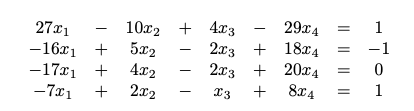

In [27]:
# Importing libary 
import numpy as np 

# Building the array matrix
A = np.array([
[27, -10, 4, -29],
[-16, 5, -2, 18],
[-17, 4, -2, 20],
[-7, 2, -1, 8]
])

# b is the right side from the equation Ax = b 
b = np.array([1, -1, 0, 1])

# Solving for x using np.linalg.solve
x = np.linalg.solve(A, b)

# Printing results
print("x =", x)

x = [10.  3. -9.  7.]


**Visualizing a Linear Transformation**

Let T be the linear transformation that takes in a vector v in R2 and outputs the product of the 2 × 2 matrix A shown below and v.

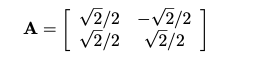

I.e., T is a function that takes in a vector v in R2 and outputs the vector T (v) = Av, also in R2

**(a) Find T(x)**

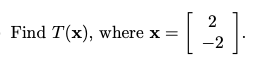

In [28]:
# Importing Libaray 
import numpy as np 

# Creating the array for A
A = np.array([
    [np.sqrt(2)/2, -np.sqrt(2)/2],
    [np.sqrt(2)/2, np.sqrt(2)/2]
])

# x is the input vector I am transforming 
x = np.array([2, -2])

# T(x) = A @ x
Tx = A @ x

# Print Results
print("T(x): ",  Tx)

T(x):  [2.82842712 0.        ]


**(b) Section 7.1.3**

Mimic the code in Section 7.1.3 of Essential Math for Data Science to visualize the linear transformation T .

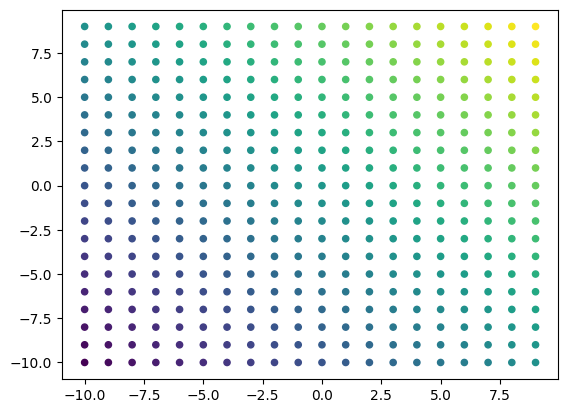

In [29]:
# Importing libarries
import numpy as np 
import matplotlib.pyplot as plt 

# evenly spaced points along the x-axis and y-axis
x = np.arange(-10, 10, 1)
y = np.arange(-10, 10, 1)

# meshgrid combines the x and y array into every possbile (x, y)
xx, yy = np.meshgrid(x, y)

# Plots the points on the grid, coloring by xx+yy to give each 
# point a different visual "tag"
plt.scatter(xx, yy, s=20, c=xx+yy)

**(c) Visualization description**
   
Use your visualization from (2) to describe geometrically how T transforms vectors in general.

**Answer:**

The visualization shows that the T rotates every vector in by 45 degrees counterclockwise. We see that the transformation preserves the lengths of the vectors and the angles between them. The grid keeps the shape and spacing but is rotated. No stretching, shrinking, or shearing occurs—only the orientation of the vectors changes.

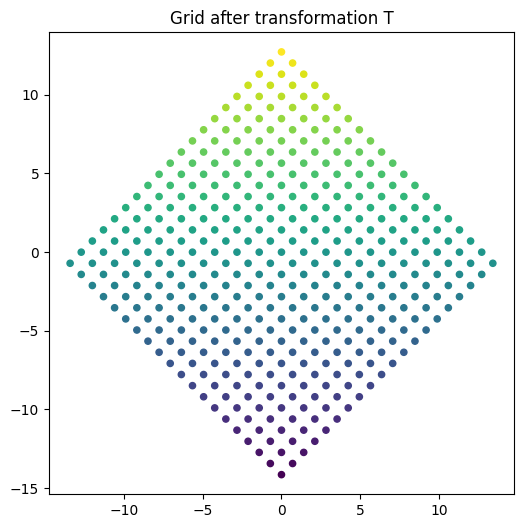

In [30]:
# Combine xx and yy into a single array of coordinate pairs.
# ravel() flattens the 2D grid into 1D arrays, then we stack them
points = np.vstack([xx.ravel(), yy.ravel()])

# Apply the transformation to every point at once: A @ points
transformed = A @ points

# Reshape the transformed x and y coordinates back into grid shape,
xx_t = transformed[0].reshape(xx.shape)
yy_t = transformed[1].reshape(yy.shape)

# Plot the transformed grid
plt.figure(figsize=(6,6))
plt.scatter(xx_t, yy_t, s=20, c=xx+yy)
plt.title("Grid after transformation T")
plt.axis('equal')
plt.show()

**Finding the Eigenvalues and Eigenvectors of a Matrix**

Let A be the matrix given below.

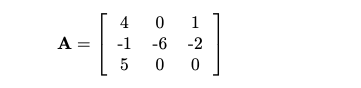

In [31]:
# Import libaries 
import numpy as np 

A = np.array([
    [4, 0, 1],
    [-1, -6, -2],
    [5, 0, 0]
])

**(a) Verify with Python** 

Is the vector [1 2 3] (vertical) an eigenvector of A? Verify your answer with a calculation in Python.

**Answer:**

A @ v1 comes out to [7, -19, 5], which is not an eigenvector. Each component divided by the corresponding component of v1 should yield the same value, but instead, the ratios differ. 

In [32]:
# Testing vector v1 to check if its an eigenvector of A
v1 = np.array([1, 2, 3])

# using A @ v1 to calcualte if v1 is an eigenvector
Av1 = A @ v1 

ratios = Av1 / v1 

# Print results 
print("A @ v1:", Av1)
print("ratios:", ratios)


A @ v1: [  7 -19   5]
ratios: [ 7.         -9.5         1.66666667]


**(b) Verify with Python**

Is the vector [0 1 0] (vertical) an eigenvector of A? Again, verify your answer with a calculation in Python.

**Answer:**

A @ v2 comes out to [0, -6, 0], which is just v2 scaled by -6, so V2 = [0, 1, 0] is an eigenvector of A with the eigenvalue at -6. 


In [33]:
# Testing vector v2 to check if its an eigenvector of A
v2 = np.array([0, 1, 0])

# using A @ v2 to calcualte if v2 is an eigenvector
Av2 = A @ v2 

# Print results 
print("A @ v2:", Av2)


A @ v2: [ 0 -6  0]


**(c) finding all the eigenvalues and eigenvectors**

Use Python to find all of the eigenvalues and eigenvectors of A.

**Answer:**

Based on the results, we can confirm that part (B) corresponds to the eigenvector [0, 1, 0] with eigenvalue -6, while the other two eigenvectors provide 5 and -1, which correspond to the remaining eigenvectors. 

In [34]:
# np.linalg.eig() computes both the eigenvalue and eigenvectors of A. 
eigenvalues, eigenvectors = np.linalg.eig(A)

# Printing results 
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Eigenvalues: [-6.  5. -1.]
Eigenvectors:
 [[ 0.          0.69431384 -0.18493168]
 [ 1.         -0.18935832 -0.33287702]
 [ 0.          0.69431384  0.9246584 ]]


**Principal Component Analysis** 

For this exercise, you will be working with the data set video game data.csv. This data has four
columns: name of the game, critic score, user score, and total sales. Note: This data set is a modified
version of the data set from https://www.kaggle.com/ashaheedq/video-games-sales-2019.

**Scatterplot**

(a) Make a scatterplot of the user scores versus critics scores.

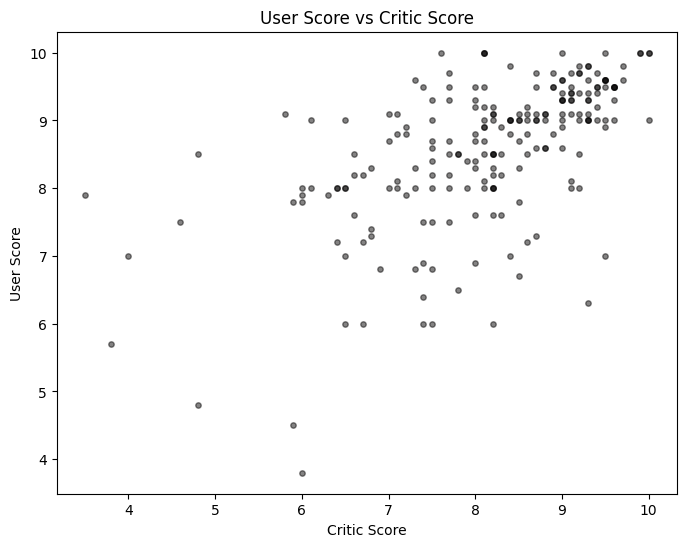

In [49]:
# Importing libaries 
import pandas as pd 
import matplotlib.pyplot as plt

# Loading dataset 
video_games = pd.read_csv('vgsales-12-4-2019-short.csv')

# Scatterplot of Critic scores on x-axis and User_score on Y
plt.figure(figsize=(8,6))
plt.scatter(video_games['Critic_Score'], video_games['User_Score'], alpha=0.5, s=15, color='#0A0909')
plt.xlabel("Critic Score")
plt.ylabel("User Score")
plt.title("User Score vs Critic Score")

plt.show()

**Approximate directions** 

(b) On your scatterplot from part (a), sketch the approximate directions of the first and second
principal components. This can be done by hand or in Python.

**Used example from the Essential Math for Data Science  pages - 351 through 359**

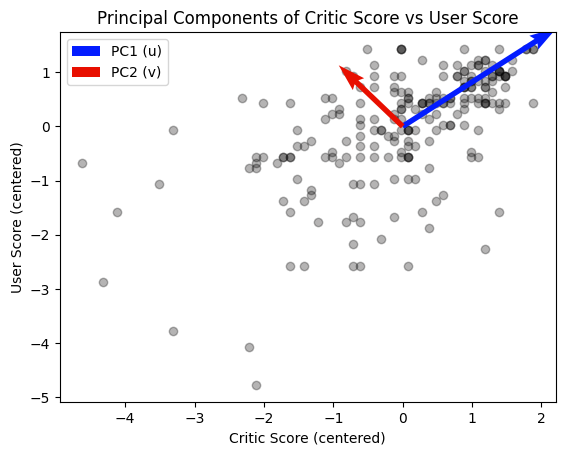

In [52]:
# Import libaries
import matplotlib.pyplot as plt
import numpy as np 
from sklearn.decomposition import PCA

# Remove rows where critic or user score is missing 
scores = video_games[['Critic_Score', 'User_Score']].dropna()

# Setting up the data matrix X with two variables 
X = np.array([scores["Critic_Score"], scores["User_Score"]]).T

# Covariance matrix: diagonal = variance of each variable 
C = np.cov(X, rowvar=False)

# Calculating the Eigenvectors of the covariance matrix 
eigvals, eigvecs = np.linalg.eig(C)
eigvals, eigvecs

# Centering the data since that is what the covariance matrix was calculated from 
X_centered = X - X.mean(axis=0)

# Storing the two eigenvectors separately
u = eigvecs[:, 0].reshape(-1, 1)
v = eigvecs[:, 1].reshape(-1, 1)

# Plotting the  eigenvectors scaled by 2 standard deviations (2 * sqrt(eigenvalue))
plt.quiver(0, 0,
           2 * np.sqrt(eigvals[0]) * u[0], 2 * np.sqrt(eigvals[0]) * u[1],
           color="#031CFF", angles='xy', scale_units='xy', scale=1,
           zorder=2, width=0.011, label="PC1 (u)")

plt.quiver(0, 0,
           2 * np.sqrt(eigvals[1]) * v[0], 2 * np.sqrt(eigvals[1]) * v[1],
           color="#E80F00", angles='xy', scale_units='xy', scale=1,
           zorder=2, width=0.011, label="PC2 (v)")


# Plotting the transformed data to check the principal components are uncorrelated
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.3, color="#0A0909") 

# Scatterplot Titles & Labels
plt.xlabel("Critic Score (centered)")
plt.ylabel("User Score (centered)")
plt.title("Principal Components of Critic Score vs User Score")
plt.legend()
plt.show()

